# EDA final · cancelación de reservas de hotel

**Máster en IA, Cloud Computing y DevOps** · Machine Learning y Deep Learning · Práctica final

Si `eda_inicial.ipynb` es la cocina, este es el escaparate: aquí **no se explora**, se
*presenta*. Solo entra lo que sobrevivió a la exploración y **cambió una decisión** del
proyecto. Cada sección termina en una frase que empieza por «Decisión:».

Las cifras salen de las mismas funciones que usa el pipeline (`src/data_loader.py`), así
que no pueden contradecir a `main.py`. La tabla del final es la del apartado 3 del README.

In [1]:
import sys, pathlib

# Subir hasta la raiz del proyecto (la carpeta que contiene src/), la abras desde donde la abras.
raiz = next(d for d in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (d / "src").is_dir())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

from src import config, data_loader

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

def es(x, dec=2):
    """Cifras como en el README: punto de miles y coma decimal."""
    return f"{x:,.{dec}f}".replace(",", "·").replace(".", ",").replace("·", ".")

In [2]:
df = data_loader.cargar_crudo()
print(f"{es(df.shape[0], 0)} filas x {df.shape[1]} columnas")
df.head()

119.390 filas x 32 columnas


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. El objetivo y su desbalanceo

El número que hunde a `accuracy` como métrica principal: un modelo que dijera siempre
«no cancela» ya acierta la mayoría sin haber aprendido nada. Y tras la limpieza de la
sección 3 el desbalanceo aumenta.

      [limpieza] fugas: -4 columnas (reservation_status, reservation_status_date, required_car_parking_spaces, assigned_room_type)
      [limpieza] duplicados exactos: -33.413 filas
      [limpieza] adr negativo: -1 filas
      [limpieza] 0 huéspedes: -165 filas
      [limpieza] total: 119.390 -> 85.811 filas


,CSV crudo,tras la limpieza
is_canceled,,
no cancela,62.96,72.36
cancela,37.04,27.64


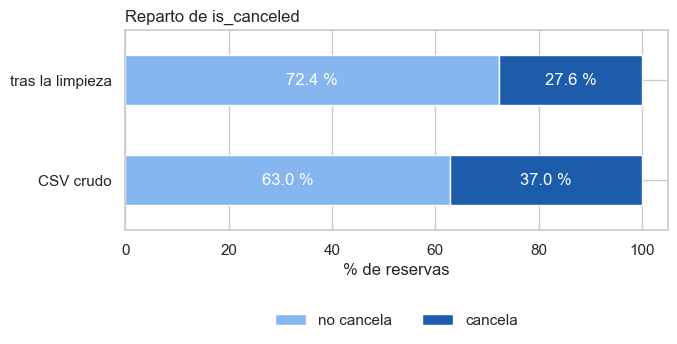

In [3]:
limpio = data_loader.limpiar(df)

reparto = pd.DataFrame({
    "CSV crudo": df[config.OBJETIVO].value_counts(normalize=True),
    "tras la limpieza": limpio[config.OBJETIVO].value_counts(normalize=True),
}).rename(index={0: "no cancela", 1: "cancela"}).mul(100).round(2)
display(reparto)

ax = reparto.T.plot.barh(stacked=True, figsize=(7, 2.6), color=["#86b6ef", "#1c5cab"])
for barras in ax.containers:
    ax.bar_label(barras, fmt="%.1f %%", label_type="center", color="white")
ax.set_xlabel("% de reservas")
ax.set_title("Reparto de is_canceled", loc="left")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.show()

**Decisión:** la métrica principal es el **F1 de la clase «cancela»**. Con los datos
limpios, el modelo trivial ya acierta el 72,36 %, así que accuracy queda como métrica
secundaria: no distingue un modelo útil de uno que no ha aprendido nada.

## 2. La fuga: columnas que son la respuesta con otro nombre

`reservation_status` determina `is_canceled` al 100 %: `Check-Out` → 0, `Canceled` y
`No-Show` → 1. Es la etiqueta escrita de otra manera.

In [4]:
tabla = pd.crosstab(df["reservation_status"], df[config.OBJETIVO])
display(tabla)

# La prueba: ninguna fila de la tabla tiene las dos columnas a la vez distintas de cero.
print("determina el objetivo al 100 %?", bool(((tabla > 0).sum(axis=1) == 1).all()))

is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


determina el objetivo al 100 %? True


Hay otras dos más discretas: se rellenan **cuando el cliente llega**, y cuando toca
predecir (al reservar o en las semanas siguientes) todavía no existen. Lo delatan los
No-Show, que nunca llegan al hotel.

In [5]:
estado = df["reservation_status"]

con_plaza = df["required_car_parking_spaces"] > 0
print(f"reservas con plaza de parking: {es(con_plaza.sum(), 0)}")
display(pd.crosstab(con_plaza.rename("con plaza"), estado))

distinta = df["assigned_room_type"] != df["reserved_room_type"]
display(distinta.groupby(estado).mean().mul(100).round(1)
        .to_frame("% con habitación distinta de la reservada"))

reservas con plaza de parking: 7.416


reservation_status,Canceled,Check-Out,No-Show
con plaza,,,
False,43017,67750,1207
True,0,7416,0


,% con habitación distinta de la reservada
reservation_status,
Canceled,1.4
Check-Out,18.8
No-Show,17.2


**Decisión:** se eliminan las cuatro columnas de `config.FUGAS`
(`reservation_status`, `reservation_status_date`, `required_car_parking_spaces` y
`assigned_room_type`). Ninguna reserva con plaza de parking está cancelada ni es No-Show,
y la habitación asignada solo cambia en el 1,4 % de las canceladas. Quedan **27
predictoras**.

## 3. Nulos, duplicados e imposibles

Cuánto se pierde en cada paso de la limpieza y por qué. La salida de `limpiar()` en la
sección 1 ya da el recuento de cada paso.

In [6]:
nulos = df.isna().mean().mul(100).round(2)
display(nulos[nulos > 0].sort_values(ascending=False).to_frame("% nulos"))

sin_fugas = df.drop(columns=config.FUGAS)
duplicada = sin_fugas.duplicated()
print(f"duplicados exactos: {es(duplicada.sum(), 0)} filas ({es(100 * duplicada.mean(), 1)} %), "
      f"de las que cancelan el {es(100 * sin_fugas.loc[duplicada, config.OBJETIVO].mean(), 1)} %")

,% nulos
company,94.31
agent,13.69
country,0.41


duplicados exactos: 33.413 filas (28,0 %), de las que cancelan el 61,3 %


¿Y si se dejaran? El CSV no trae identificador de reserva: una copia en train y su
gemela en test harían que el modelo se examine de algo que ya ha visto. Se comprueba
partiendo el CSV **sin deduplicar**, con la misma semilla y `stratify`.

In [7]:
X_crudo, y_crudo = data_loader.separar_X_y(df)
X_tr, X_te, y_tr, y_te = data_loader.particionar(X_crudo, y_crudo)

huella = lambda X, y: pd.util.hash_pandas_object(pd.concat([X, y], axis=1), index=False)
gemela = huella(X_te, y_te).isin(set(huella(X_tr, y_tr)))
print(f"filas de test con una gemela exacta en train: {es(gemela.sum(), 0)} de "
      f"{es(len(X_te), 0)} ({es(100 * gemela.mean(), 1)} %)")
print(f"cancelan: {es(100 * y_te[gemela].mean(), 1)} % las que tienen gemela, "
      f"{es(100 * y_te[~gemela].mean(), 1)} % el resto")

filas de test con una gemela exacta en train: 7.813 de 23.878 (32,7 %)


cancelan: 58,2 % las que tienen gemela, 26,7 % el resto


**Decisión:** se eliminan los duplicados exactos (después de quitar las fugas y antes
de partir) y los imposibles: 1 reserva con `adr` negativo y 165 sin ningún huésped. De
119.390 filas quedan **85.811**. Los nulos no se borran: se imputan dentro del Pipeline
(sección 4).

## 4. Cardinalidad: qué pasa si haces one-hot de todo

`country`, `agent` y `company` tienen cientos de valores distintos. Un one-hot a lo
bruto multiplica las columnas y deja categorías con tres reservas.

In [8]:
d = data_loader.preparar()
X_train = d["X_train"]

display(X_train[config.ALTA_CARDINALIDAD].nunique().to_frame("valores distintos en train"))

numericas = [c for c in X_train.select_dtypes("number").columns if c not in config.ALTA_CARDINALIDAD]
categoricas = [c for c in X_train.columns if c not in numericas]
ingenuo = len(numericas) + sum(X_train[c].nunique(dropna=False) for c in categoricas)
agrupado = clone(d["preprocesador"]).fit(X_train).transform(X_train.head()).shape[1]
print(f"one-hot ingenuo: {ingenuo} columnas | top-{config.TOP_N_CATEGORIAS} + cajón: {agrupado} columnas")

      [limpieza] fugas: -4 columnas (reservation_status, reservation_status_date, required_car_parking_spaces, assigned_room_type)
      [limpieza] duplicados exactos: -33.413 filas
      [limpieza] adr negativo: -1 filas
      [limpieza] 0 huéspedes: -165 filas
      [limpieza] total: 119.390 -> 85.811 filas
      train 68.648 / test 17.163 filas | cancelan: 27.64% en train, 27.64% en test


,valores distintos en train
country,168
agent,325
company,320


one-hot ingenuo: 880 columnas | top-10 + cajón: 97 columnas


**Decisión:** las tres se agrupan en sus 10 valores más frecuentes más un cajón para
el resto, y el nulo de `agent` y `company` es una categoría propia (no hay agente =
reserva directa). Se aprende dentro del Pipeline, fold a fold: de 880 columnas a **97**.

## 5. Dónde está la señal: tasa de cancelación por grupo

Una variable es útil si la tasa de cancelación **cambia mucho** entre sus categorías. Se
mide sobre los datos limpios, que son los que ve el modelo.

In [9]:
def tasa_por(col, datos, minimo=300):
    """Tasa de cancelacion por categoria, ignorando las categorias con pocos casos."""
    g = datos.groupby(col)[config.OBJETIVO].agg(tasa="mean", reservas="size")
    return g[g["reservas"] >= minimo].sort_values("tasa", ascending=False)

for col in ["deposit_type", "market_segment", "customer_type", "hotel"]:
    display(tasa_por(col, limpio).style.format({"tasa": "{:.1%}"}))

display(tasa_por("country", limpio).head(10).style.format({"tasa": "{:.1%}"}))

,tasa,reservas
deposit_type,,
Non Refund,94.9%,1011
No Deposit,26.8%,84707


,tasa,reservas
market_segment,,
Online TA,35.3%,51271
Groups,28.2%,4409
Offline TA/TO,14.9%,13438
Direct,14.7%,11688
Complementary,12.5%,682
Corporate,12.1%,4095


,tasa,reservas
customer_type,,
Transient,30.1%,71439
Contract,16.4%,3121
Transient-Party,15.2%,10714
Group,9.9%,537


,tasa,reservas
hotel,,
City Hotel,30.2%,52413
Resort Hotel,23.6%,33398


,tasa,reservas
country,,
AGO,56.3%,341
CHN,48.4%,805
RUS,39.9%,552
BRA,36.5%,1979
PRT,35.9%,26742
ITA,35.3%,3009
ISR,33.8%,391
NOR,28.1%,508
ESP,26.0%,7132


`deposit_type = "Non Refund"` es el caso raro: en el CSV crudo cancela casi siempre,
pero eran sobre todo copias de reservas de grupo. Al deduplicar se queda en una fracción.

In [10]:
for nombre, datos in [("CSV crudo", df), ("limpio", limpio)]:
    nr = datos[datos["deposit_type"] == "Non Refund"]
    print(f"{nombre:>9}: {es(len(nr), 0):>6} reservas Non Refund, cancelan el {es(100 * nr[config.OBJETIVO].mean(), 1)} %")

CSV crudo: 14.587 reservas Non Refund, cancelan el 99,4 %


   limpio:  1.011 reservas Non Refund, cancelan el 94,9 %


**Decisión:** se conservan todas. `deposit_type`, `market_segment`, `customer_type` y
`country` separan con claridad. `country` es la que más pesa y tiene una duda
declarada en el apartado 10 del README: en los No-Show se parece a las canceladas, como
las fugas de la sección 2.

## 6. Las numéricas que más separan

`lead_time` es la candidata clara: cuanto antes reservas, más margen hay para arrepentirse.

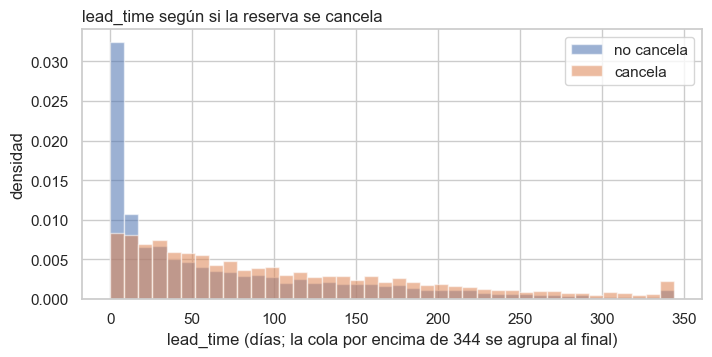

,lead_time,adr,total_of_special_requests,previous_cancellations,booking_changes
is_canceled,,,,,
no cancela,37.0,95.0,1.0,0.0,0.0
cancela,79.0,109.8,0.0,0.0,0.0


adr máximo: 5400.0 | siguiente: 510.0


In [11]:
cola = limpio["lead_time"].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 3.5))
for clase, nombre in [(0, "no cancela"), (1, "cancela")]:
    valores = limpio.loc[limpio[config.OBJETIVO] == clase, "lead_time"]
    ax.hist(valores.clip(upper=cola), bins=40, density=True, alpha=0.55, label=nombre)
ax.set_xlabel(f"lead_time (días; la cola por encima de {cola:.0f} se agrupa al final)")
ax.set_ylabel("densidad")
ax.set_title("lead_time según si la reserva se cancela", loc="left")
ax.legend()
plt.show()

display(limpio.groupby(config.OBJETIVO)[["lead_time", "adr", "total_of_special_requests",
                                         "previous_cancellations", "booking_changes"]]
        .median().rename(index={0: "no cancela", 1: "cancela"}))
print("adr máximo:", limpio["adr"].max(), "| siguiente:", limpio["adr"].nlargest(2).iloc[-1])

**Decisión:** las numéricas se imputan con la **mediana** (lead_time y adr tienen la
cola larga a la derecha) y se escalan, todo dentro del Pipeline. No se recortan los
extremos: el `adr` de 5.400 es raro pero no imposible, y con esta partición cae en el
test, así que no toca el escalado.

## 7. La tabla que va al README

El apartado 3 del README se puntúa por lo que **cambió**, no por el número de gráficos.
Las cifras salen de las celdas de arriba.

In [12]:
mediana_lt = limpio.groupby(config.OBJETIVO)["lead_time"].median()
hallazgos = pd.DataFrame([
    ("Clases desbalanceadas",
     f"Tras limpiar, {es(100 * (1 - limpio[config.OBJETIVO].mean()))} % no cancela (62,96 % en crudo)",
     "F1 de la clase «cancela» como métrica principal; accuracy, secundaria"),
    ("`reservation_status` es la respuesta",
     "Check-Out → 0; Canceled y No-Show → 1, sin excepciones",
     "Se elimina, junto con su fecha"),
    ("Parking y habitación asignada se rellenan al llegar",
     f"{es(con_plaza.sum(), 0)} reservas con plaza: ninguna cancelada ni No-Show",
     "Se eliminan: quedan 27 predictoras"),
    ("Duplicados exactos",
     f"{es(duplicada.sum(), 0)} filas ({es(100 * duplicada.mean(), 1)} %); sin quitarlos, el "
     f"{es(100 * gemela.mean(), 1)} % del test tendría una gemela en train",
     "Se eliminan antes de partir: 85.811 filas"),
    ("Registros imposibles",
     "1 reserva con adr negativo y 165 sin ningún huésped",
     "Se eliminan"),
    ("Alta cardinalidad",
     f"country, agent y company: {', '.join(str(v) for v in X_train[config.ALTA_CARDINALIDAD].nunique())} "
     f"valores; one-hot ingenuo de {ingenuo} columnas",
     f"Top-10 + cajón dentro del Pipeline: {agrupado} columnas"),
    ("Nulos con significado",
     f"agent {es(100 * X_train['agent'].isna().mean(), 1)} % y company "
     f"{es(100 * X_train['company'].isna().mean(), 1)} % nulos en train",
     "El nulo es su propia categoría: sin agente = reserva directa"),
    ("lead_time separa",
     f"Mediana de {mediana_lt[1]:.0f} días si cancela frente a {mediana_lt[0]:.0f} si no",
     "Se mantiene; mediana para imputar y escalado, dentro del Pipeline"),
], columns=["Hallazgo", "Evidencia", "Decisión que tomamos"])

display(hallazgos)
print(hallazgos.to_markdown(index=False))  # copiar y pegar en el README

,Hallazgo,Evidencia,Decisión que tomamos
0,Clases desbalanceadas,"Tras limpiar, 72,36 % no cancela (62,96 % en c...",F1 de la clase «cancela» como métrica principa...
1,`reservation_status` es la respuesta,"Check-Out → 0; Canceled y No-Show → 1, sin exc...","Se elimina, junto con su fecha"
2,Parking y habitación asignada se rellenan al l...,7.416 reservas con plaza: ninguna cancelada ni...,Se eliminan: quedan 27 predictoras
3,Duplicados exactos,"33.413 filas (28,0 %); sin quitarlos, el 32,7 ...",Se eliminan antes de partir: 85.811 filas
4,Registros imposibles,1 reserva con adr negativo y 165 sin ningún hu...,Se eliminan
5,Alta cardinalidad,"country, agent y company: 168, 325, 320 valore...",Top-10 + cajón dentro del Pipeline: 97 columnas
6,Nulos con significado,"agent 13,7 % y company 94,1 % nulos en train",El nulo es su propia categoría: sin agente = r...
7,lead_time separa,Mediana de 79 días si cancela frente a 37 si no,"Se mantiene; mediana para imputar y escalado, ..."


| Hallazgo                                            | Evidencia                                                                            | Decisión que tomamos                                                  |
|:----------------------------------------------------|:-------------------------------------------------------------------------------------|:----------------------------------------------------------------------|
| Clases desbalanceadas                               | Tras limpiar, 72,36 % no cancela (62,96 % en crudo)                                  | F1 de la clase «cancela» como métrica principal; accuracy, secundaria |
| `reservation_status` es la respuesta                | Check-Out → 0; Canceled y No-Show → 1, sin excepciones                               | Se elimina, junto con su fecha                                        |
| Parking y habitación asignada se rellenan al llegar | 7.416 reservas con plaza: ninguna cancelada ni No-Show                              